# Model 2C, Logistic Regression Experiment 02: Taxi-Out and Schedule-Margin Representations

This experiment tests whether a different representation of information already available at takeoff improves Model 2C. It does not create or load another feature dataset. Three variants use the existing `JFK_YEAR_arrivals.csv` dataset:

1. the exact 31-field Logistic Regression 2C Experiment 01 control;
2. raw `TaxiOut` in place of `LOG_TAXI_OUT_MINUTES`;
3. the raw-taxi allowlist plus a nonlinear spline of `MINUTES_TO_SCHEDULED_ARRIVAL`.

`MINUTES_TO_SCHEDULED_ARRIVAL` equals `CRSElapsedTime - DepDelay - TaxiOut`. It is calculated inside this notebook and is not saved. A plain linear version would repeat information already present in the component fields, so the third variant fits a spline inside each training fold.

The variant, classifier settings, and operating threshold are selected only from five expanding 2019 folds. The selected design is refitted on all 2019 rows and evaluated once on 2023. The 2024 dataset is not loaded.

In [1]:
AIRPORT = "JFK"
TRAIN_YEAR = 2019
VALIDATION_YEAR = 2023
TARGET = "ArrDel15"

RANDOM_STATE = 42
N_TIME_SPLITS = 5
N_JOBS = 4
SPLINE_KNOTS = 5
SPLINE_DEGREE = 3

In [2]:
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    f1_score,
    make_scorer,
    matthews_corrcoef,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, SplineTransformer, StandardScaler

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

## Load and validate the shared arrival datasets

The experiment uses the same 2019 training rows and 2023 validation rows as Logistic Regression 2C Experiment 01 and CatBoost 2C Experiment 01.

In [3]:
def find_project_root(start: Path, airport: str, years) -> Path:
    required = [
        Path("data/features") / f"{airport}_{year}_arrivals.csv"
        for year in years
    ]
    for candidate in (start, *start.parents):
        if all((candidate / path).is_file() for path in required):
            return candidate
    raise FileNotFoundError(f"Could not locate required feature datasets: {required}")


PROJECT_ROOT = find_project_root(
    Path.cwd().resolve(),
    AIRPORT,
    [TRAIN_YEAR, VALIDATION_YEAR],
)
TRAIN_DATA_PATH = PROJECT_ROOT / "data/features" / f"{AIRPORT}_{TRAIN_YEAR}_arrivals.csv"
VALIDATION_DATA_PATH = PROJECT_ROOT / "data/features" / f"{AIRPORT}_{VALIDATION_YEAR}_arrivals.csv"

train_df = pd.read_csv(TRAIN_DATA_PATH, low_memory=False)
validation_df = pd.read_csv(VALIDATION_DATA_PATH, low_memory=False)


def validate_source_frame(frame: pd.DataFrame, year: int, partition: str):
    required = {"FlightDate", "Dest", TARGET}
    missing = sorted(required.difference(frame.columns))
    assert not missing, f"{partition} missing columns: {missing}"
    frame["FlightDate"] = pd.to_datetime(frame["FlightDate"], errors="raise")
    assert frame["FlightDate"].dt.year.eq(year).all()
    assert frame["Dest"].eq(AIRPORT).all()
    assert frame[TARGET].notna().all()
    assert set(frame[TARGET].unique()).issubset({0, 0.0, 1, 1.0})
    return {
        "partition": partition,
        "year": year,
        "start": frame["FlightDate"].min().date(),
        "end": frame["FlightDate"].max().date(),
        "days": frame["FlightDate"].dt.normalize().nunique(),
        "rows": len(frame),
        "delayed_flights": int(frame[TARGET].sum()),
        "delay_rate": frame[TARGET].mean(),
    }


source_summary = pd.DataFrame([
    validate_source_frame(train_df, TRAIN_YEAR, "training"),
    validate_source_frame(validation_df, VALIDATION_YEAR, "external validation"),
]).set_index("partition")
source_summary

,year,start,end,days,rows,delayed_flights,delay_rate
partition,,,,,,,
training,2019,2019-01-01,2019-12-31,365,107354,21784,0.2029
external validation,2023,2023-01-01,2023-12-31,365,109947,27077,0.2463


## Define the control and model-side variants

Every variant keeps the 27-field Model 2A base and signed `DepDelay`. The control retains log taxi-out duration and cyclical takeoff time. The other variants replace the log with raw `TaxiOut`; no variant includes both raw and log taxi-out.

The schedule-margin spline uses the same 31 source fields as the raw-taxi variant. Its calculated margin is an additional model-side input, not a saved feature-dataset field.

In [4]:
MODEL_2A_CATEGORICAL_FEATURES = [
    "Reporting_Airline",
    "Origin",
]

MODEL_2A_NUMERIC_FEATURES = [
    "SCHED_DEP_TIME_SIN",
    "SCHED_DEP_TIME_COS",
    "SCHED_ARR_TIME_SIN",
    "SCHED_ARR_TIME_COS",
    "DAY_OF_WEEK_SIN",
    "DAY_OF_WEEK_COS",
    "DAY_OF_YEAR_SIN",
    "DAY_OF_YEAR_COS",
    "IS_WEEKEND",
    "CRSElapsedTime",
    "LOG_DISTANCE",
    "SCHEDULED_SPEED_PROXY",
    "ASPM_THREE_HOUR_SCHEDULED_DEPARTURES",
    "ASPM_THREE_HOUR_SCHEDULED_ARRIVALS",
    "ASPM_CURRENT_MINUS_PREVIOUS_TRAFFIC",
    "ASPM_NEXT_MINUS_CURRENT_TRAFFIC",
    "ASPM_MAX_HOURLY_TRAFFIC",
    "HourlyDryBulbTemperature",
    "TEMP_DEWPOINT_SPREAD",
    "LOG_PRECIPITATION",
    "HourlyVisibility",
    "WindX",
    "WindY",
    "ADVERSE_WEATHER",
    "NOAA_AGE_MINUTES",
]

TAKEOFF_TIME_FEATURES = [
    "ACTUAL_TAKEOFF_TIME_SIN",
    "ACTUAL_TAKEOFF_TIME_COS",
]
CONTROL_NUMERIC_FEATURES = [
    *MODEL_2A_NUMERIC_FEATURES,
    "DepDelay",
    "LOG_TAXI_OUT_MINUTES",
    *TAKEOFF_TIME_FEATURES,
]
RAW_TAXI_NUMERIC_FEATURES = [
    *MODEL_2A_NUMERIC_FEATURES,
    "DepDelay",
    "TaxiOut",
    *TAKEOFF_TIME_FEATURES,
]
CALCULATED_MARGIN = "MINUTES_TO_SCHEDULED_ARRIVAL"

variant_definitions = {
    "control_log_taxi": {
        "source_numeric": CONTROL_NUMERIC_FEATURES,
        "use_margin_spline": False,
    },
    "raw_taxi": {
        "source_numeric": RAW_TAXI_NUMERIC_FEATURES,
        "use_margin_spline": False,
    },
    "raw_taxi_margin_spline": {
        "source_numeric": RAW_TAXI_NUMERIC_FEATURES,
        "use_margin_spline": True,
    },
}

for name, definition in variant_definitions.items():
    source_fields = MODEL_2A_CATEGORICAL_FEATURES + definition["source_numeric"]
    assert len(source_fields) == len(set(source_fields)) == 31, name

required_source_columns = set(MODEL_2A_CATEGORICAL_FEATURES)
for definition in variant_definitions.values():
    required_source_columns.update(definition["source_numeric"])

required_columns = [
    "FlightDate",
    "Dest",
    "CRSDepTime",
    TARGET,
    *sorted(required_source_columns),
]
for partition, frame in [("training", train_df), ("external validation", validation_df)]:
    missing = sorted(set(required_columns).difference(frame.columns))
    assert not missing, f"{partition} missing required columns: {missing}"

forbidden_predictors = {
    TARGET,
    "DepTime",
    "DepDelayMinutes",
    "DepDel15",
    "DepartureDelayGroups",
    "ACTUAL_DEP_MINUTE_OF_DAY",
    "ACTUAL_DEP_TIME_SIN",
    "ACTUAL_DEP_TIME_COS",
    "DEPARTED_EARLY",
    "LOG_DEP_DELAY_MINUTES",
    "WheelsOff",
    "ACTUAL_TAKEOFF_MINUTE_OF_DAY",
    "ArrTime",
    "ArrDelay",
    "ArrDelayMinutes",
    "ArrivalDelayGroups",
    "WheelsOn",
    "TaxiIn",
    "ActualElapsedTime",
    "AirTime",
    "Tail_Number",
}
assert not forbidden_predictors.intersection(required_source_columns)

pd.DataFrame([
    {
        "variant": name,
        "source_fields": 31,
        "taxi_representation": (
            "log" if "LOG_TAXI_OUT_MINUTES" in definition["source_numeric"] else "raw"
        ),
        "calculated_margin": definition["use_margin_spline"],
        "margin_treatment": (
            f"degree-{SPLINE_DEGREE} spline with {SPLINE_KNOTS} quantile knots"
            if definition["use_margin_spline"] else "none"
        ),
    }
    for name, definition in variant_definitions.items()
]).set_index("variant")

,source_fields,taxi_representation,calculated_margin,margin_treatment
variant,,,,
control_log_taxi,31,log,False,none
raw_taxi,31,raw,False,none
raw_taxi_margin_spline,31,raw,True,degree-3 spline with 5 quantile knots


## Calculate the row-level margin and create chronological folds

The schedule margin uses only values known when the target flight takes off. It is calculated independently for each row and does not learn from other rows. The spline knots, missing-value handling, scaling, category encoding, classifier settings, and threshold are learned within the 2019 training process.

In [5]:
def prepare_model_frame(source: pd.DataFrame) -> pd.DataFrame:
    frame = source[required_columns].copy()
    frame = frame.sort_values(["FlightDate", "CRSDepTime"], kind="stable").reset_index(drop=True)
    frame[TARGET] = pd.to_numeric(frame[TARGET], errors="raise").astype(int)

    for column in MODEL_2A_CATEGORICAL_FEATURES:
        frame[column] = frame[column].astype(object)
    for column in required_source_columns.difference(MODEL_2A_CATEGORICAL_FEATURES):
        frame[column] = pd.to_numeric(frame[column], errors="coerce")

    frame[CALCULATED_MARGIN] = (
        frame["CRSElapsedTime"] - frame["DepDelay"] - frame["TaxiOut"]
    )
    return frame


train_model_df = prepare_model_frame(train_df)
validation_model_df = prepare_model_frame(validation_df)
y_train = train_model_df[TARGET].reset_index(drop=True)
y_validation = validation_model_df[TARGET].reset_index(drop=True)
training_dates = train_model_df["FlightDate"].reset_index(drop=True)
validation_dates = validation_model_df["FlightDate"].reset_index(drop=True)

assert training_dates.max() < validation_dates.min()
assert train_model_df[CALCULATED_MARGIN].notna().all()
assert validation_model_df[CALCULATED_MARGIN].notna().all()

margin_summary = pd.DataFrame({
    "training": train_model_df[CALCULATED_MARGIN].describe(),
    "external_validation": validation_model_df[CALCULATED_MARGIN].describe(),
})
margin_summary

,training,external_validation
count,"107,354.0000","109,947.0000"
mean,178.5130,165.9134
std,113.4119,117.9957
min,"-1,392.0000","-2,266.0000"
25%,97.0000,94.0000
50%,161.0000,148.0000
75%,288.0000,264.0000
max,578.0000,601.0000


In [6]:
def make_expanding_day_splits(dates: pd.Series, targets: pd.Series, n_splits: int):
    normalized = dates.dt.normalize().to_numpy()
    unique_days = np.array(sorted(pd.unique(normalized)))
    day_blocks = np.array_split(unique_days, n_splits + 1)
    splits, rows = [], []

    for fold in range(1, n_splits + 1):
        train_days = np.concatenate(day_blocks[:fold])
        heldout_days = day_blocks[fold]
        train_idx = np.flatnonzero(np.isin(normalized, train_days))
        heldout_idx = np.flatnonzero(np.isin(normalized, heldout_days))
        assert train_days.max() < heldout_days.min()
        splits.append((train_idx, heldout_idx))
        rows.append({
            "fold": fold,
            "train_rows": len(train_idx),
            "validation_rows": len(heldout_idx),
            "train_end": pd.Timestamp(train_days.max()).date(),
            "validation_start": pd.Timestamp(heldout_days.min()).date(),
            "validation_end": pd.Timestamp(heldout_days.max()).date(),
            "train_delay_rate": targets.iloc[train_idx].mean(),
            "validation_delay_rate": targets.iloc[heldout_idx].mean(),
        })

    return splits, pd.DataFrame(rows).set_index("fold")


temporal_splits, fold_summary = make_expanding_day_splits(
    training_dates,
    y_train,
    N_TIME_SPLITS,
)
fold_summary

,train_rows,validation_rows,train_end,validation_start,validation_end,train_delay_rate,validation_delay_rate
fold,,,,,,,
1,17776,18725,2019-03-02,2019-03-03,2019-05-02,0.2082,0.1834
2,36501,18153,2019-05-02,2019-05-03,2019-07-02,0.1955,0.2319
3,54654,17703,2019-07-02,2019-07-03,2019-09-01,0.2076,0.2646
4,72357,17650,2019-09-01,2019-09-02,2019-11-01,0.2215,0.1474
5,90007,17347,2019-11-01,2019-11-02,2019-12-31,0.2070,0.1818


## Select the variant and logistic-regression settings using 2019

The three representations are first screened with Logistic Regression 2C Experiment 01's fixed classifier: L1 regularization, `C=0.1`, and no class weighting. Each representation uses the same five chronological folds. Mean average precision selects one representation.

Only the selected representation receives a compact 12-configuration search over `C` values 0.01, 0.1, and 1.0, L1 versus L2 regularization, and no class weighting versus balanced weighting. The previously tested `C=10` setting is omitted because it did not win Experiment 01 and produced impractically long fits in the initial Experiment 02 run. The schedule-margin spline learns its quantile knots separately inside each training fold.

In [7]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler()),
])
margin_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    (
        "spline",
        SplineTransformer(
            n_knots=SPLINE_KNOTS,
            degree=SPLINE_DEGREE,
            knots="quantile",
            extrapolation="linear",
            include_bias=False,
        ),
    ),
    ("scaler", StandardScaler()),
])


def make_pipeline(definition):
    transformers = [
        ("categorical", categorical_pipeline, MODEL_2A_CATEGORICAL_FEATURES),
        ("numeric", numeric_pipeline, definition["source_numeric"]),
    ]
    if definition["use_margin_spline"]:
        transformers.append(("schedule_margin", margin_pipeline, [CALCULATED_MARGIN]))

    return Pipeline([
        (
            "preprocessor",
            ColumnTransformer(transformers=transformers, remainder="drop"),
        ),
        (
            "classifier",
            LogisticRegression(
                solver="liblinear",
                max_iter=5_000,
                random_state=RANDOM_STATE,
            ),
        ),
    ])


def variant_model_columns(definition):
    columns = [
        *MODEL_2A_CATEGORICAL_FEATURES,
        *definition["source_numeric"],
    ]
    if definition["use_margin_spline"]:
        columns.append(CALCULATED_MARGIN)
    return columns


search_start = perf_counter()
screen_rows = []

for variant_name, definition in variant_definitions.items():
    model_columns = variant_model_columns(definition)
    X_variant = train_model_df[model_columns].reset_index(drop=True)
    fixed_pipeline = make_pipeline(definition).set_params(
        classifier__C=0.1,
        classifier__l1_ratio=1.0,
        classifier__class_weight=None,
    )

    for fold_number, (train_idx, heldout_idx) in enumerate(temporal_splits, start=1):
        fold_model = clone(fixed_pipeline)
        fold_model.fit(X_variant.iloc[train_idx], y_train.iloc[train_idx])
        probabilities = fold_model.predict_proba(X_variant.iloc[heldout_idx])[:, 1]
        screen_rows.append({
            "variant": variant_name,
            "fold": fold_number,
            "average_precision": average_precision_score(
                y_train.iloc[heldout_idx], probabilities
            ),
            "roc_auc": roc_auc_score(y_train.iloc[heldout_idx], probabilities),
            "brier_score": brier_score_loss(y_train.iloc[heldout_idx], probabilities),
        })

screen_results = pd.DataFrame(screen_rows)
representation_summary = (
    screen_results
    .groupby("variant", as_index=False)
    .agg(
        screen_mean_average_precision=("average_precision", "mean"),
        screen_std_average_precision=("average_precision", "std"),
        screen_mean_roc_auc=("roc_auc", "mean"),
        screen_mean_brier_score=("brier_score", "mean"),
    )
    .sort_values(
        ["screen_mean_average_precision", "screen_mean_roc_auc"],
        ascending=False,
    )
    .reset_index(drop=True)
)

selected_variant = str(representation_summary.iloc[0]["variant"])
selected_definition = variant_definitions[selected_variant]
selected_model_columns = variant_model_columns(selected_definition)
X_selected = train_model_df[selected_model_columns].reset_index(drop=True)

parameter_grid = {
    "classifier__C": [0.01, 0.1, 1.0],
    "classifier__l1_ratio": [1.0, 0.0],
    "classifier__class_weight": [None, "balanced"],
}
scoring = {
    "average_precision": "average_precision",
    "roc_auc": "roc_auc",
    "balanced_accuracy": "balanced_accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": "recall",
    "f1": "f1",
    "mcc": make_scorer(matthews_corrcoef),
    "neg_brier": "neg_brier_score",
}

selected_search = GridSearchCV(
    estimator=make_pipeline(selected_definition),
    param_grid=parameter_grid,
    scoring=scoring,
    refit="average_precision",
    cv=temporal_splits,
    n_jobs=N_JOBS,
    pre_dispatch=N_JOBS,
    verbose=0,
    return_train_score=False,
    error_score="raise",
)
selected_search.fit(X_selected, y_train)
best_pipeline = selected_search.best_estimator_

tuning_results = pd.DataFrame(selected_search.cv_results_)
best_tuning_row = tuning_results.iloc[selected_search.best_index_]
best_parameters = selected_search.best_params_
selected_penalty = "l1" if best_parameters["classifier__l1_ratio"] == 1.0 else "l2"

variant_summary = representation_summary.rename(columns={
    "screen_mean_average_precision": "best_mean_average_precision",
    "screen_mean_roc_auc": "best_mean_roc_auc",
    "screen_mean_brier_score": "best_mean_brier_score",
}).copy()
variant_summary["C"] = 0.1
variant_summary["penalty"] = "l1"
variant_summary["class_weight"] = "None"
variant_summary["selection_stage"] = "fixed representation screen"

selected_mask = variant_summary["variant"].eq(selected_variant)
variant_summary.loc[selected_mask, "best_mean_average_precision"] = (
    selected_search.best_score_
)
variant_summary.loc[selected_mask, "best_mean_roc_auc"] = (
    best_tuning_row["mean_test_roc_auc"]
)
variant_summary.loc[selected_mask, "best_mean_brier_score"] = (
    -best_tuning_row["mean_test_neg_brier"]
)
variant_summary.loc[selected_mask, "C"] = best_parameters["classifier__C"]
variant_summary.loc[selected_mask, "penalty"] = selected_penalty
variant_summary.loc[selected_mask, "class_weight"] = str(
    best_parameters["classifier__class_weight"]
)
variant_summary.loc[selected_mask, "selection_stage"] = "selected and tuned"

search_seconds = perf_counter() - search_start
print(f"Representation screen and tuning completed in {search_seconds:,.1f} seconds")
print(f"Selected variant: {selected_variant}")
print(f"Selected parameters: {best_parameters}")
display(representation_summary)
variant_summary

/Users/johnkyte/Projects/berkeley_ml_and_ai/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Representation screen and tuning completed in 104.2 seconds
Selected variant: raw_taxi_margin_spline
Selected parameters: {'classifier__C': 0.1, 'classifier__class_weight': None, 'classifier__l1_ratio': 1.0}


,variant,screen_mean_average_precision,screen_std_average_precision,screen_mean_roc_auc,screen_mean_brier_score
0,raw_taxi_margin_spline,0.9081,0.0211,0.9534,0.0541
1,raw_taxi,0.9042,0.0218,0.9502,0.0549
2,control_log_taxi,0.9013,0.0227,0.9492,0.0560


,variant,best_mean_average_precision,screen_std_average_precision,best_mean_roc_auc,best_mean_brier_score,C,penalty,class_weight,selection_stage
0,raw_taxi_margin_spline,0.9081,0.0211,0.9534,0.0541,0.1000,l1,None,selected and tuned
1,raw_taxi,0.9042,0.0218,0.9502,0.0549,0.1000,l1,None,fixed representation screen
2,control_log_taxi,0.9013,0.0227,0.9492,0.0560,0.1000,l1,None,fixed representation screen


## Select the operating threshold using 2019 only

The selected variant and classifier settings are refitted once per chronological fold. Thresholds from 0.05 through 0.50 are ranked by F1 on held-out 2019 probabilities, with balanced accuracy and precision as tie-breakers.

In [8]:
def evaluate_probabilities(y_true, probabilities, threshold):
    predictions = (np.asarray(probabilities) >= threshold).astype(int)
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_true, predictions),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "f1": f1_score(y_true, predictions, zero_division=0),
        "mcc": matthews_corrcoef(y_true, predictions),
        "roc_auc": roc_auc_score(y_true, probabilities),
        "average_precision": average_precision_score(y_true, probabilities),
        "brier_score": brier_score_loss(y_true, probabilities),
    }


X_train_selected = train_model_df[selected_model_columns].reset_index(drop=True)
X_validation_selected = validation_model_df[selected_model_columns].reset_index(drop=True)
oof_probabilities = np.full(len(y_train), np.nan)

for train_idx, heldout_idx in temporal_splits:
    fold_model = clone(best_pipeline)
    fold_model.fit(X_train_selected.iloc[train_idx], y_train.iloc[train_idx])
    oof_probabilities[heldout_idx] = fold_model.predict_proba(
        X_train_selected.iloc[heldout_idx]
    )[:, 1]

oof_mask = np.isfinite(oof_probabilities)
oof_y = y_train.to_numpy()[oof_mask]
oof_p = oof_probabilities[oof_mask]
threshold_results = pd.DataFrame([
    evaluate_probabilities(oof_y, oof_p, threshold)
    for threshold in np.round(np.arange(0.05, 0.501, 0.01), 2)
])
selected_threshold = float(
    threshold_results.sort_values(
        ["f1", "balanced_accuracy", "precision"],
        ascending=False,
    ).iloc[0]["threshold"]
)

print(f"Threshold-selection rows: {oof_mask.sum():,}")
print(f"Training-only selected threshold: {selected_threshold:.2f}")
threshold_results.sort_values(
    ["f1", "balanced_accuracy", "precision"],
    ascending=False,
).head(10)

Threshold-selection rows: 89,578
Training-only selected threshold: 0.45


,threshold,accuracy,balanced_accuracy,precision,recall,f1,mcc,roc_auc,average_precision,brier_score
40,0.4500,0.9306,0.8713,0.8695,0.7720,0.8178,0.7772,0.9382,0.8912,0.0543
41,0.4600,0.9308,0.8703,0.8734,0.7688,0.8178,0.7777,0.9382,0.8912,0.0543
42,0.4700,0.9311,0.8694,0.8769,0.7661,0.8177,0.7782,0.9382,0.8912,0.0543
43,0.4800,0.9311,0.8683,0.8797,0.7629,0.8172,0.7779,0.9382,0.8912,0.0543
45,0.5000,0.9316,0.8664,0.8876,0.7570,0.8171,0.7791,0.9382,0.8912,0.0543
44,0.4900,0.9313,0.8672,0.8834,0.7598,0.8169,0.7783,0.9382,0.8912,0.0543
39,0.4400,0.9299,0.8717,0.8647,0.7740,0.8169,0.7755,0.9382,0.8912,0.0543
38,0.4300,0.9295,0.8724,0.8607,0.7767,0.8165,0.7746,0.9382,0.8912,0.0543
37,0.4200,0.9291,0.8732,0.8566,0.7794,0.8161,0.7737,0.9382,0.8912,0.0543
36,0.4100,0.9286,0.8739,0.8522,0.7821,0.8156,0.7726,0.9382,0.8912,0.0543


## Refit the selected design on 2019 and evaluate 2023

Only the variant selected from 2019 is evaluated on 2023. Logistic Regression 2C Experiment 01 is included as the documented fixed comparison and is not refitted here.

In [9]:
final_fit_start = perf_counter()
best_pipeline.fit(X_train_selected, y_train)
final_fit_seconds = perf_counter() - final_fit_start
validation_probabilities = best_pipeline.predict_proba(X_validation_selected)[:, 1]

evaluation_results = pd.DataFrame([
    {
        "model": "Logistic Regression 2C-01 (documented)",
        "threshold": 0.49,
        "accuracy": 0.9206,
        "balanced_accuracy": 0.8620,
        "precision": 0.9156,
        "recall": 0.7464,
        "f1": 0.8224,
        "mcc": 0.7786,
        "roc_auc": 0.9457,
        "average_precision": 0.9090,
        "brier_score": 0.0616,
    },
    {
        "model": "Logistic Regression 2C-02 (default)",
        **evaluate_probabilities(y_validation, validation_probabilities, 0.50),
    },
    {
        "model": "Logistic Regression 2C-02 (training-selected)",
        **evaluate_probabilities(
            y_validation,
            validation_probabilities,
            selected_threshold,
        ),
    },
]).set_index("model")

print(f"Final all-2019 fit completed in {final_fit_seconds:,.1f} seconds")
evaluation_results

Final all-2019 fit completed in 6.1 seconds


,threshold,accuracy,balanced_accuracy,precision,recall,f1,mcc,roc_auc,average_precision,brier_score
model,,,,,,,,,,
Logistic Regression 2C-01 (documented),0.4900,0.9206,0.8620,0.9156,0.7464,0.8224,0.7786,0.9457,0.9090,0.0616
Logistic Regression 2C-02 (default),0.5000,0.9241,0.8664,0.9249,0.7528,0.8300,0.7886,0.9491,0.9145,0.0594
Logistic Regression 2C-02 (training-selected),0.4500,0.9239,0.8712,0.9098,0.7672,0.8324,0.7885,0.9491,0.9145,0.0594


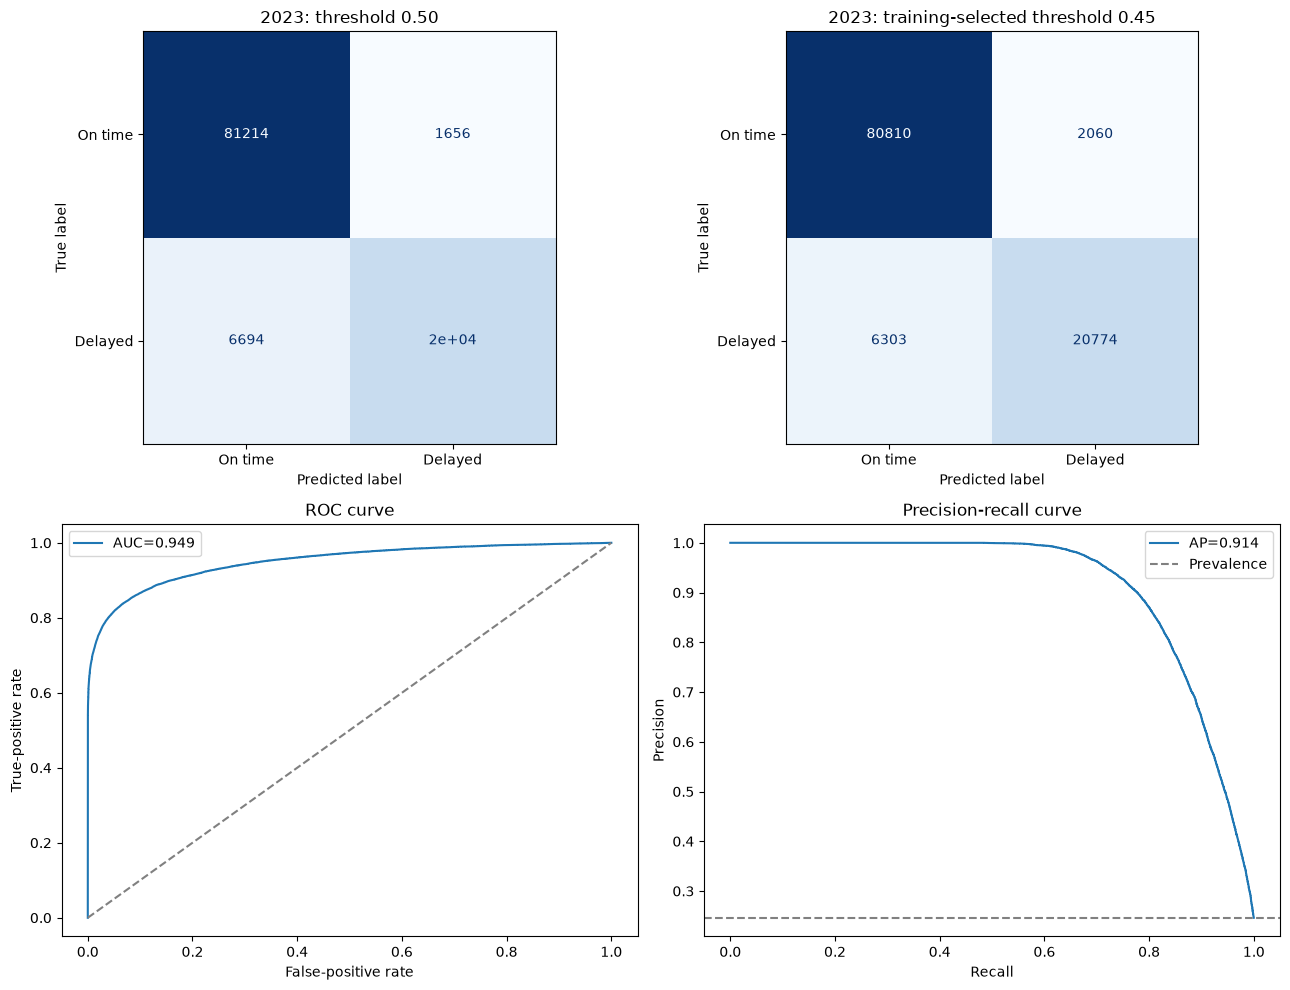

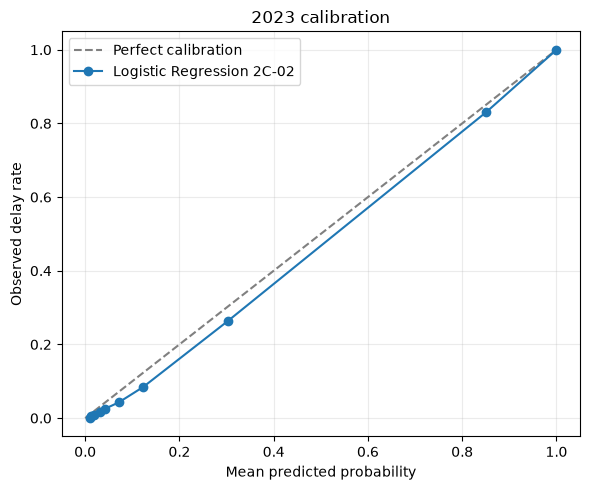

In [10]:
default_predictions = (validation_probabilities >= 0.50).astype(int)
selected_predictions = (validation_probabilities >= selected_threshold).astype(int)
false_positive_rate, true_positive_rate, _ = roc_curve(
    y_validation, validation_probabilities
)
curve_precision, curve_recall, _ = precision_recall_curve(
    y_validation, validation_probabilities
)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
ConfusionMatrixDisplay.from_predictions(
    y_validation,
    default_predictions,
    display_labels=["On time", "Delayed"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0, 0],
)
axes[0, 0].set_title("2023: threshold 0.50")
ConfusionMatrixDisplay.from_predictions(
    y_validation,
    selected_predictions,
    display_labels=["On time", "Delayed"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0, 1],
)
axes[0, 1].set_title(f"2023: training-selected threshold {selected_threshold:.2f}")
axes[1, 0].plot(
    false_positive_rate,
    true_positive_rate,
    label=f"AUC={roc_auc_score(y_validation, validation_probabilities):.3f}",
)
axes[1, 0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1, 0].set(
    xlabel="False-positive rate",
    ylabel="True-positive rate",
    title="ROC curve",
)
axes[1, 0].legend()
axes[1, 1].plot(
    curve_recall,
    curve_precision,
    label=f"AP={average_precision_score(y_validation, validation_probabilities):.3f}",
)
axes[1, 1].axhline(
    y_validation.mean(), linestyle="--", color="gray", label="Prevalence"
)
axes[1, 1].set(
    xlabel="Recall",
    ylabel="Precision",
    title="Precision-recall curve",
)
axes[1, 1].legend()
fig.tight_layout()
plt.show()

predicted, observed = calibration_curve(
    y_validation,
    validation_probabilities,
    n_bins=10,
    strategy="quantile",
)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
ax.plot(predicted, observed, marker="o", label="Logistic Regression 2C-02")
ax.set(
    xlabel="Mean predicted probability",
    ylabel="Observed delay rate",
    title="2023 calibration",
)
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Inspect coefficients and publishable values

Coefficient magnitude is comparable only within the prepared and standardized design. The spline basis represents ranges of the calculated schedule margin; individual spline coefficients should not be interpreted as separate operational effects.

In [11]:
preprocessor = best_pipeline.named_steps["preprocessor"]
classifier = best_pipeline.named_steps["classifier"]
prepared_feature_names = preprocessor.get_feature_names_out()
coefficient_table = (
    pd.DataFrame({
        "feature": prepared_feature_names,
        "coefficient": classifier.coef_[0],
    })
    .assign(abs_coefficient=lambda frame: frame["coefficient"].abs())
    .sort_values("abs_coefficient", ascending=False)
    .reset_index(drop=True)
)
display(coefficient_table.head(25))
display(
    coefficient_table[
        coefficient_table["feature"].str.contains(
            "TaxiOut|TAXI_OUT|MINUTES_TO_SCHEDULED_ARRIVAL",
            regex=True,
        )
    ]
)

default = evaluation_results.loc["Logistic Regression 2C-02 (default)"]
selected = evaluation_results.loc["Logistic Regression 2C-02 (training-selected)"]
selected_summary = variant_summary.set_index("variant").loc[selected_variant]
publishable_summary = pd.Series({
    "selected variant": selected_variant,
    "source fields": 31,
    "calculated model-side fields": int(
        variant_definitions[selected_variant]["use_margin_spline"]
    ),
    "prepared predictors": len(prepared_feature_names),
    "selected C": selected_summary["C"],
    "selected penalty": selected_summary["penalty"],
    "selected class weighting": selected_summary["class_weight"],
    "training CV AP": selected_summary["best_mean_average_precision"],
    "validation prevalence": y_validation.mean(),
    "validation AP": default["average_precision"],
    "validation ROC AUC": default["roc_auc"],
    "validation Brier": default["brier_score"],
    "selected threshold": selected_threshold,
    "selected-threshold accuracy": selected["accuracy"],
    "selected-threshold balanced accuracy": selected["balanced_accuracy"],
    "selected-threshold precision": selected["precision"],
    "selected-threshold recall": selected["recall"],
    "selected-threshold F1": selected["f1"],
    "selected-threshold MCC": selected["mcc"],
    "search seconds": search_seconds,
    "final fit seconds": final_fit_seconds,
}, name="Logistic Regression 2C Experiment 02 Appendix F values")
publishable_summary.to_frame()

,feature,coefficient,abs_coefficient
0,schedule_margin__MINUTES_TO_SCHEDULED_ARRIVAL_...,7.9208,7.9208
1,numeric__DepDelay,6.3566,6.3566
2,numeric__SCHEDULED_SPEED_PROXY,2.8828,2.8828
3,schedule_margin__MINUTES_TO_SCHEDULED_ARRIVAL_...,2.0520,2.0520
4,categorical__Origin_SJU,1.2570,1.2570
5,categorical__Origin_RDU,-1.1222,1.1222
6,numeric__TaxiOut,1.0360,1.0360
7,categorical__Origin_CLT,-0.9102,0.9102
8,categorical__Origin_DFW,0.7482,0.7482
9,categorical__Origin_BNA,0.6784,0.6784


,feature,coefficient,abs_coefficient
0,schedule_margin__MINUTES_TO_SCHEDULED_ARRIVAL_...,7.9208,7.9208
3,schedule_margin__MINUTES_TO_SCHEDULED_ARRIVAL_...,2.0520,2.0520
6,numeric__TaxiOut,1.0360,1.0360
21,schedule_margin__MINUTES_TO_SCHEDULED_ARRIVAL_...,-0.3398,0.3398
79,schedule_margin__MINUTES_TO_SCHEDULED_ARRIVAL_...,0.0000,0.0000
80,schedule_margin__MINUTES_TO_SCHEDULED_ARRIVAL_...,0.0000,0.0000
107,schedule_margin__MINUTES_TO_SCHEDULED_ARRIVAL_...,0.0000,0.0000


,Logistic Regression 2C Experiment 02 Appendix F values
selected variant,raw_taxi_margin_spline
source fields,31
calculated model-side fields,1
prepared predictors,108
selected C,0.1000
selected penalty,l1
selected class weighting,None
training CV AP,0.9081
validation prevalence,0.2463
validation AP,0.9145


## Interpretation checklist

1. Does raw taxi-out improve 2019 temporal average precision over the log representation?
2. Does the fold-fitted schedule-margin spline add useful nonlinear information?
3. Does the selected 2019 result persist in 2023 average precision, ROC AUC, Brier score, F1, or MCC?
4. Is any improvement large enough to justify the additional transformation?
5. Keep the existing saved arrival feature dataset unchanged.
6. Keep the 2024 dataset untouched until the final classifier and threshold are selected.